# Density Estimation in 1-dimensional Setting Using Basis Functions Centered at Grid Points

This Jupyter notebook demonstrates how to use functions in `dekef` to estimate probability density functions in a kernel exponential family using the score matching loss function and the negative log-likelihood loss function, and visualize the resulting density estimates in the 1-dimensional setting. 

The basis functions in the natural parameter are the kernel functions centered at a set of pre-specified grid points. 

The dataset used here is the eruption data from the Old Faithful geyser in Yellowstone National Park in Wyoming and was first published by [Azzalini and Bowman (1990)](https://www.jstor.org/stable/2347385?seq=1). This dataset consists of 299 observations collected continuously from August 1, 1985 to August 15, 1985, and contain 2 variables, namely, the `eruption` variable (the duration of this eruption) and the `waiting` variable (the waiting time for this eruption). Both variables are measured in the unit of minute. 

For the illustrative purpose, we focus on the `waiting` variable only. 

We first import the modules needed. 

In [7]:
import os
import numpy as np
import pandas as pd

from dekef.base_density import *
from dekef.kernel_function import *
from dekef.data_median_dist import *
from dekef.negloglik_params import *

# from dekef.negloglik_grid_points import *
# from dekef.scorematching_penalized_grid_points import *

from dekef.plot_density_1d import *

from IPython.display import Markdown as md

import warnings
warnings.filterwarnings('ignore')
np.random.seed(1989)

## Load the data

We now load the data in the following cell. 

In [2]:
os.chdir('../data')
true_data = np.load('geyser.npy').astype(np.float64)
waiting = true_data[:, 0].reshape(-1, 1)

We look at the histogram of the `waiting` variable. 

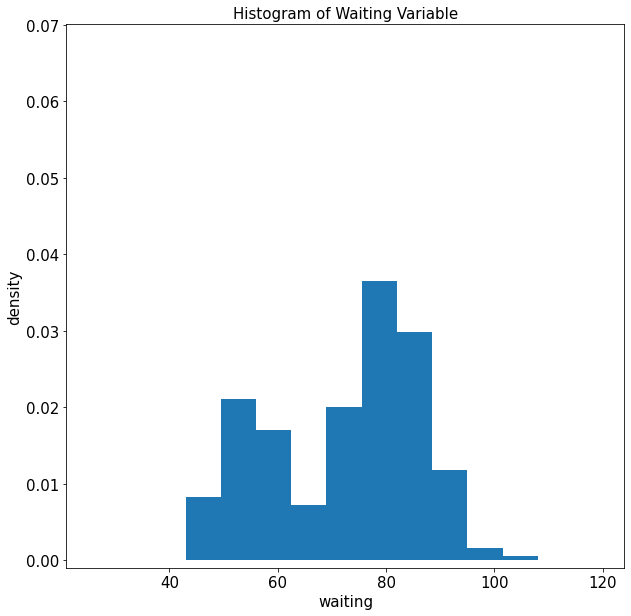

In [3]:
# set plot parameters
font_size = 15
xlimit = (21., 124.)
ylimit = (-0.001, 0.0701)

# plot the histogram of waiting variable 
ax = pd.Series(waiting.flatten()).hist(grid = False, figsize = (10, 10), bins = 'fd', density = True)
ax.set_xlim(xlimit)
ax.set_ylim(ylimit)
ax.set_title('Histogram of Waiting Variable', fontsize = font_size)
ax.set_xlabel('waiting', fontsize = font_size)
ax.set_ylabel('density', fontsize = font_size)
ax.tick_params(axis = 'both', labelsize = font_size)

We choose the kernel function in the kernel exponential family to be the Gaussian kernel whose bandwidth is equal to $0.4$ times the median of pairwise distances of data. The median of pairwise distances of data can be computed using the `data_median_dist` function. 

The grid points at which we center the kernel functions are $1, 2, \cdots, 200$. 

In [4]:
bw = 5.0
grid_points = np.arange(1., 311.).reshape(-1, 1)

We choose the base density in the kernel exponential family to be the probability density function of the Gamma distribution whose parameters are estimated by the method of the maximum likelihood. 

In [5]:
base_density = BasedenGamma(waiting)

## Penalized Score Matching Density Estimation

We now demonstrate how to estimate density functions using the penalized score matching density estimation method at a single penalty parameter $\lambda > 0$. The main function that achieves this is the `coef` function in the class `ScoreMatchingPenalizedGridPoints`, which yields the coefficients of basis functions of the natural parameter. 

In [ ]:
sm_pen = ScoreMatchingPenalizedGridPoints(
    data = waiting, 
    grid_points = grid_points,
    base_density = base_density,
    kernel_type = 'gaussian_poly2', 
    kernel_r1 = 1.0, 
    kernel_r2 = 0.0, 
    kernel_c = 0.0, 
    kernel_bw = bw)

In [ ]:
# Here, we choose the penalty parameter to be exp(-10.0), supplied using the lambda_param argument. 
coef_smpen = sm_pen.coef(
    data = waiting, 
    lambda_param = np.exp(-10.0))

Next, we visualize the resulting score matching density estimate together with the histogram. The main function that achieves this is `plot_density_1d`. Besides exhibiting the plot of the density estimate, this function also returns the points at which the density values are estimated and plotted and the resulting estimates. 

In [ ]:
# specify the plotting parameters 
plot_params = plot_density_1d_params(xlimit, ylimit)

# visualize density estimate
den_vals = plot_density_1d(
    data = waiting, 
    kernel_function = kernel_function, 
    base_density = base_density, 
    basis_type = 'grid_points', 
    coef = coef_smpen, 
    normalizing = True, 
    method = 'penalized score matching', 
    x_label = 'waiting',
    grid_points = grid_points,
    save_plot = False, 
    save_dir = None, 
    save_filename = None, 
    plot_kwargs = plot_params)

It is typical that the best penalty parameter $\lambda > 0$ is unknown. With a list of candidates of penalty parameters, we can use the [cross validation](https://en.wikipedia.org/wiki/Cross-validation_(statistics)#:~:text=Cross%2Dvalidation%2C%20sometimes%20called%20rotation,to%20an%20independent%20data%20set.) to select the best one. The main function that achieves this is `optlambda` in the class `ScoreMatchingPenalized`, which returns the optimal penalty parameter and the corresponding coefficient vector of basis functions in the natural parameter. 

In [ ]:
opt_smpen = sm_pen.optlambda(
    lambda_cand = np.exp(np.linspace(-10.0, -2.0, 9)), 
    k_folds = 3,
    save_dir = None, 
    save_info = False)

The optimal parameter is {{np.format_float_scientific(x = opt_smpen['opt_lambda'], precision = 5)}} whose logarithm is {{np.log(opt_smpen['opt_lambda'])}}. We now plot the corresponding density estimate below.

In [ ]:
# visualize the optimal density estimate
den_vals = plot_density_1d(
    data = waiting, 
    kernel_function = kernel_function, 
    base_density = base_density, 
    basis_type = 'grid_points', 
    coef = opt_smpen['opt_coef'], 
    normalizing = True, 
    method = 'penalized score matching', 
    x_label = 'waiting',
    grid_points = grid_points,
    save_plot = False, 
    save_dir = None, 
    save_filename = None, 
    plot_kwargs = plot_params)

## Negative Log-likelihood Density Estimation

In order to estimate density functions using the penalized negative log-likelihood loss function at a single penalty parameter $\lambda > 0$ and using the basis functions that are identical to the score matching density estimators, we use the function `coef` in the class `NegLogLikGridPoints`, which yields the coefficients of basis functions in the natural parameter. 

In [12]:
# set parameters for computing the density estimate
bmc_params = batch_montecarlo_params(
    mc_batch_size = 5000, 
    mc_tol = 1e-3)

gdalgo_params = negloglik_optalgo_params(
    start_pt = np.zeros((grid_points.shape[0], 1)), 
    step_size = 1.0, 
    max_iter = 50, 
    rel_tol = 1e-5, 
    abs_tol = 0.05
)

In [20]:
waiting = waiting[waiting != 108.].reshape(-1, 1)
np.max(waiting)

98.0

In [21]:
# Here, we choose the penalty parameter to be exp(-5.0), supplied using the lambda_param argument. 
nll_pen = NegLogLikGridPoints(
    data = waiting, 
    grid_points = grid_points, 
    base_density = base_density,
    kernel_type = 'gaussian_poly2', 
    kernel_r1 = 1.0, 
    kernel_r2 = 0.0, 
    kernel_c = 0.0, 
    kernel_bw = bw
)

(310, 1)


In [22]:
nll_pen_coef = nll_pen.coef(
    data = waiting, 
    lambda_param = np.exp(-10.0), 
    optalgo_params = gdalgo_params, 
    batchmc_params = bmc_params, 
    batch_mc = True, 
    print_error = True
)

(310, 310)
(310, 298)
(310, 1)
(310, 1)
(310, 1)
Iter = 1, GradNorm = 0.690403996005789, Relative Error = 1.0
(310, 1)
Iter = 2, GradNorm = 0.4904350179246334, Relative Error = 0.7103594717903706
(310, 1)
Iter = 3, GradNorm = 0.591856777638528, Relative Error = 0.8572615179845589
(310, 1)
Iter = 4, GradNorm = 0.7518837542166759, Relative Error = 1.0890489605601463
(310, 1)
Iter = 5, GradNorm = 0.9964343473027001, Relative Error = 1.4432627172892916
(310, 1)
Iter = 6, GradNorm = 0.9539547973840778, Relative Error = 1.381734177239726
(310, 1)
Iter = 7, GradNorm = 0.8509587105797319, Relative Error = 1.2325518326991212
(310, 1)
Iter = 8, GradNorm = 0.8676350527406552, Relative Error = 1.2567063020495324
(310, 1)
Iter = 9, GradNorm = 0.9321830743572639, Relative Error = 1.3501994191085875
(310, 1)
Iter = 10, GradNorm = 0.938986371578239, Relative Error = 1.360053500574417
(310, 1)
Iter = 11, GradNorm = 0.9612097828029615, Relative Error = 1.392242496225213
(310, 1)
Iter = 12, GradNorm = 1.

KeyboardInterrupt: 

In [ ]:
# specify the plotting parameters 
plot_params = plot_density_1d_params(xlimit, ylimit)

# visualize density estimate
den_vals = plot_density_1d(
    data = waiting, 
    kernel_function = kernel_function, 
    base_density = base_density, 
    basis_type = 'grid_points', 
    coef = nll_pen_coef, 
    normalizing = True, 
    method = 'negative log-likelihood (smbasis)', 
    x_label = 'waiting',
    grid_points = grid_points, 
    save_plot = False, 
    save_dir = None, 
    save_filename = None, 
    plot_kwargs = plot_params)

In [ ]:
np.random.seed(0)

nll_algo_params_cv = negloglik_optalgo_params(
    start_pt = np.zeros((waiting.shape[0], 1)), 
    step_size = [0.05, 0.02, 0.005], 
    max_iter = 20, 
    rel_tol = 3e-2, 
    abs_tol = 0.05
)

coef_nll_pen_gubasis = nll_pen_gubasis.penalized_optlambda(
    lambda_cand = np.exp(np.array([-10., -5., 0.])), 
    k_folds = 2, 
    print_error = True, 
    optalgo_params = nll_algo_params_cv, 
    batchmc_params = batchmc_params,
    save_dir = None, 
    save_info = False, 
    batch_mc=True)

In [ ]:
# specify the plotting parameters 
plot_params = plot_density_1d_params(xlimit, ylimit)

# visualize density estimate
den_vals = plot_density_1d(
    data = waiting, 
    kernel_function = kernel_function, 
    base_density = base_density, 
    basis_type = 'gubasis', 
    coef = coef_nll_pen_gubasis['opt_coef'], 
    normalizing = True, 
    method = 'negative log-likelihood (gubasis)', 
    x_label = 'waiting',
    grid_points = None,
    save_plot = False, 
    save_dir = None, 
    save_filename = None, 
    plot_kwargs = plot_params)